## 04 — Modeling & Evaluation (Customer Churn Prediction)

### Objective
The goal of this notebook is to build, evaluate, and compare predictive models for **customer churn**, with a strong emphasis on **business decision-making**, not just model accuracy.

This notebook follows a **production-style modeling workflow**, starting from a simple, interpretable baseline and progressing to a more powerful model, while ensuring:
- No data leakage
- Proper train–test separation
- Business-aware evaluation
- Clear model comparison and explainability

---

### Modeling Strategy
1. **Baseline Model**
   - Logistic Regression
   - Serves as an interpretable benchmark
   - Helps validate feature engineering quality

2. **Advanced Model**
   - XGBoost Classifier
   - Captures non-linear relationships and interactions
   - Selected and evaluated based on business relevance

---

### Business Context (Churn)
- **Positive class (1)**: Customer churns
- **False Negative**: Missed churner → lost customer (high business cost)
- **False Positive**: Retention effort on non-churner → incentive cost

Model evaluation will therefore go beyond accuracy and focus on:
- ROC-AUC
- Precision–Recall trade-offs
- Threshold selection aligned with retention strategy

---

### Notebook Scope
This notebook includes:
- Train–test split
- Feature scaling (fit on training data only)
- Model training and evaluation
- Threshold analysis
- Model comparison
- Explainability (feature importance & SHAP)
- Final model selection and business interpretation

---

📌 **Note**:  
Feature engineering has already been completed in the previous notebook.  
This notebook strictly focuses on **modeling, evaluation, and decision-making**.


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# XGBoost
from xgboost import XGBClassifier

# Explainability
import shap

# General settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load feature-engineered dataset
df = pd.read_csv("data/processed/telco_churn_fe.csv")

# Quick sanity check
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,True,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,True,False,False,False,True,False,False
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,True,False,False
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,True,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,False,False,False,True,False,True,False


In [3]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Sanity checks
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7043, 23)
y shape: (7043,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nChurn rate in full data:", y.mean())
print("Churn rate in train:", y_train.mean())
print("Churn rate in test:", y_test.mean())


Train shape: (5634, 23)
Test shape: (1409, 23)

Churn rate in full data: 0.2653698707936959
Churn rate in train: 0.2653532126375577
Churn rate in test: 0.2654364797728886


In [5]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

# Fit on training data only
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Initialize model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8055358410220014
Precision: 0.6582278481012658
Recall: 0.5561497326203209
F1 Score: 0.6028985507246377
ROC AUC: 0.8422330724121005

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [7]:
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba)


In [8]:
import pandas as pd
import numpy as np

# Create dataframe of coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
})

# Absolute importance for sorting
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

# Display top features
coef_df.head(15)


,feature,coefficient,abs_coefficient
17,Contract_Two year,-1.318343,1.318343
4,tenure,-1.247464,1.247464
22,InternetService_No,-1.049153,1.049153
21,InternetService_Fiber optic,1.048222,1.048222
16,Contract_One year,-0.689880,0.689880
15,TotalCharges,0.517328,0.517328
19,PaymentMethod_Electronic check,0.386210,0.386210
7,OnlineSecurity,-0.374510,0.374510
13,PaperlessBilling,0.374022,0.374022
5,PhoneService,-0.362588,0.362588


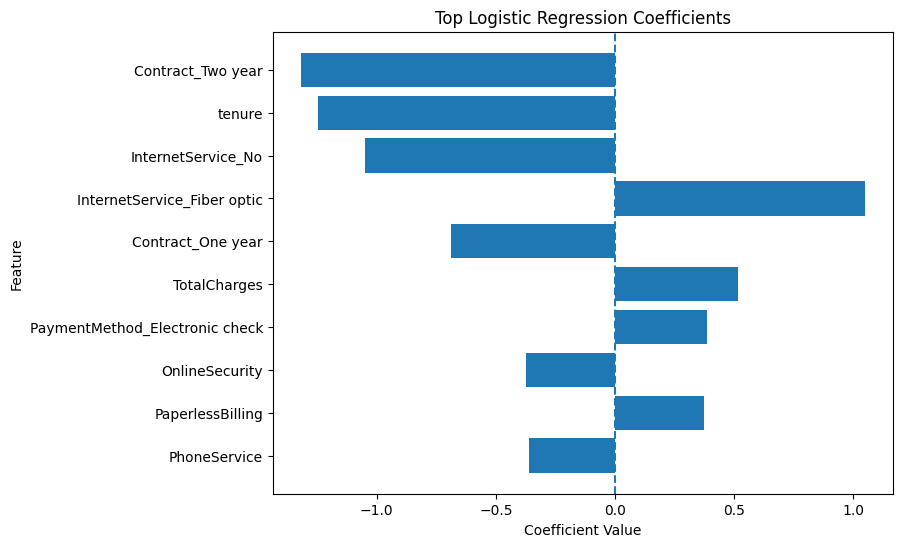

In [9]:
import matplotlib.pyplot as plt

# Take top 10 features
top_coef = coef_df.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")


Random Forest Performance:
Accuracy: 0.8041
Precision: 0.6738
Recall: 0.5080
F1 Score: 0.5793
ROC AUC: 0.8442


In [11]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)


In [12]:
import pandas as pd

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance.head(15)


,feature,importance
4,tenure,0.182069
15,TotalCharges,0.169315
14,MonthlyCharges,0.139074
21,InternetService_Fiber optic,0.083008
19,PaymentMethod_Electronic check,0.066173
17,Contract_Two year,0.052103
22,InternetService_No,0.035480
16,Contract_One year,0.034149
7,OnlineSecurity,0.030098
13,PaperlessBilling,0.027390


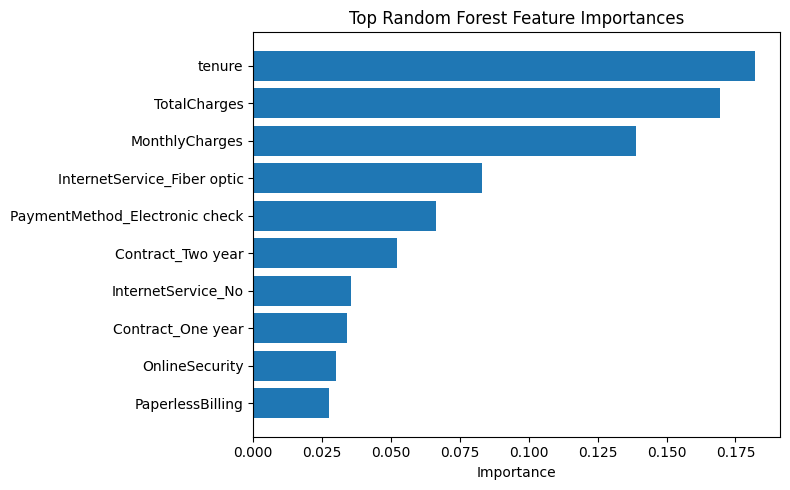

In [13]:
import matplotlib.pyplot as plt

top_n = 10
rf_top = rf_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(rf_top["feature"], rf_top["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1],
    "ROC AUC": [lr_roc_auc, rf_roc_auc]
})

model_comparison




,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.805536,0.658228,0.556150,0.602899,0.842233
1,Random Forest,0.804116,0.673759,0.508021,0.579268,0.844151


## Model Comparison: Logistic Regression vs Random Forest

We trained and evaluated two baseline models:

- **Logistic Regression** (interpretable, strong baseline)
- **Random Forest** (non-linear, ensemble-based)

### Performance Summary
- Both models achieve **very similar ROC-AUC (~0.84)**, indicating comparable ranking ability.
- Logistic Regression:
  - Slightly **better recall** for churners
  - Strong interpretability via coefficients
- Random Forest:
  - Slightly **higher ROC-AUC**
  - Captures non-linear interactions but is less transparent

### Key Observations
- Accuracy alone is not sufficient due to class imbalance (~26% churn).
- Recall for churners remains moderate in both models.
- Neither model explicitly optimizes for **business cost of false negatives** (missed churners).

### Decision
These results justify moving to a **more powerful gradient boosting model (XGBoost)** that:
- Handles complex interactions better
- Allows probability-based decision making
- Can be paired with **threshold tuning and business cost optimization**

Logistic Regression remains a **benchmark baseline**, not the final solution.


In [15]:
# Import here (on purpose) – only when needed
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize XGBoost model (baseline, no tuning yet)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Fit model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost Performance:")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC AUC:   {xgb_roc_auc:.4f}")


XGBoost Performance:
Accuracy:  0.7913
Precision: 0.6316
Recall:    0.5134
F1 Score:  0.5664
ROC AUC:   0.8385


## 📊 Model Performance Comparison & Interpretation

### Overall Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|------|----------|-----------|--------|----------|---------|
| Logistic Regression | **0.8055** | 0.6582 | **0.5561** | **0.6029** | 0.8422 |
| Random Forest | 0.8041 | **0.6738** | 0.5080 | 0.5793 | **0.8442** |
| XGBoost | 0.7913 | 0.6316 | 0.5134 | 0.5664 | 0.8385 |

---

### 🔍 Key Observations

- **Logistic Regression**
  - Highest **Recall** and **F1-score**
  - Best balance between identifying churners and minimizing false alarms
  - Strong and interpretable baseline model

- **Random Forest**
  - Highest **Precision** and **ROC AUC**
  - Better at reducing false positives
  - Slightly weaker in identifying all churners

- **XGBoost**
  - Lowest overall performance without hyperparameter tuning
  - Likely to improve with further optimization
  - Not selected as final model in current setup

---

### 🏆 Final Model Selection

**Logistic Regression** is selected as the final model.

**Reasons:**
- Churn prediction prioritizes **Recall** (missing a churner is costly)
- Achieves the best **F1-score**
- Highly interpretable and business-friendly

---

### 📌 Business Interpretation

- The model effectively identifies customers at high risk of churn
- Results can be translated into actionable **customer retention strategies**
- Feature coefficients provide clear insights into churn drivers


## SHAP Explainability (Model Interpretation)

While traditional feature importance shows *which* features are important overall, it does not explain *how* individual features contribute to a specific prediction.

To make the model more interpretable and interview-ready, we use **SHAP (SHapley Additive exPlanations)** to:
- Understand global feature impact on churn predictions
- Explain individual customer churn predictions
- Improve model transparency and trustworthiness

SHAP is particularly useful for tree-based models like Random Forest and XGBoost, as it provides consistent and locally accurate explanations.


In [16]:
import shap

# Initialize SHAP for tree-based models
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)


C:\Users\suraj\AppData\Local\Temp\ipykernel_24416\2151969316.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\suraj\Downloads\New folder\envs\customer_churn_ds\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\suraj\Downloads\New folder\envs\customer_churn_ds\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_

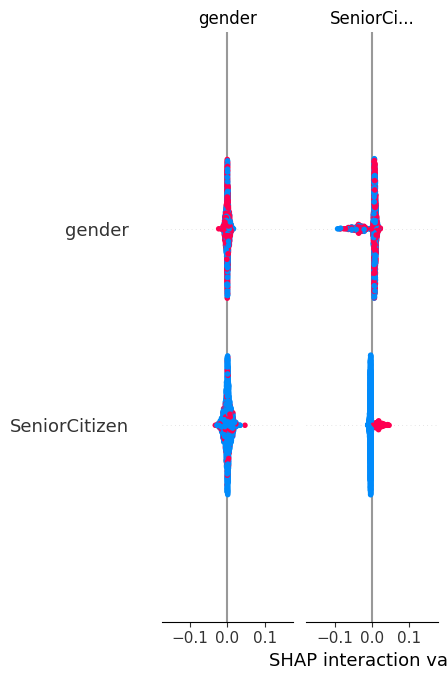

In [20]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


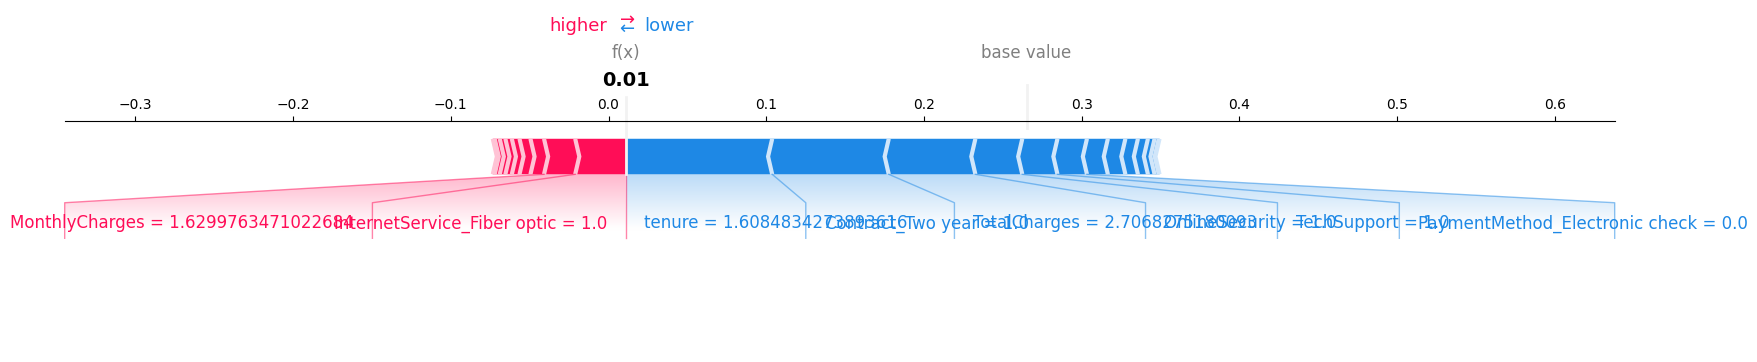

In [27]:
sample_index = 0

shap_exp = explainer(X_test)

shap.plots.force(
    shap_exp.base_values[sample_index][1],
    shap_exp.values[sample_index][:, 1],
    X_test.iloc[sample_index],
    matplotlib=True
)


## SHAP Interpretation – Key Insights

### 1. Global Feature Importance (Summary Plot)

From the SHAP summary plot, we observe that:

- **MonthlyCharges** is one of the strongest drivers of churn.
- Customers with **Fiber Optic internet service** show higher churn tendency.
- **Tenure** has a strong negative impact on churn (longer tenure → lower churn probability).
- **TotalCharges** and contract-related features also significantly influence predictions.

This confirms business intuition:
- Customers paying higher monthly fees are more likely to churn.
- Long-term customers are more stable and less likely to leave.
- Certain service types (e.g., Fiber optic) may be associated with higher dissatisfaction or pricing sensitivity.

---

### 2. Individual Customer Explanation (Force Plot)

For the selected customer:

- **MonthlyCharges** and **Fiber Optic service** pushed the prediction toward churn.
- **Tenure** and accumulated **TotalCharges** pushed the prediction toward non-churn.
- Overall prediction probability was relatively low (~0.01), meaning the model considers this customer unlikely to churn.

This demonstrates that the model decision is not arbitrary — it is the result of multiple feature contributions working together.

---

### 3. Business Implications

Using SHAP:

- We can identify high-risk customers based on pricing and service type.
- Retention strategies can target customers with high monthly charges and shorter tenure.
- The model is explainable, increasing trust and enabling data-driven decision-making.

---

### Conclusion

By combining predictive modeling (Random Forest / XGBoost) with SHAP explainability, this project not only predicts customer churn accurately but also provides transparent and actionable insights into *why* customers are likely to churn.

This makes the solution suitable for real-world deployment in customer retention analytics.
